In [1]:
import os
from pathlib import Path
import pandas as pd

data_dir = Path('data_prepaired')
detection_datasets = []

for dataset_dir in data_dir.iterdir():
    if dataset_dir.is_dir():
        detection_datasets.append(dataset_dir.name)

print(f"Datasets for training: {detection_datasets}")

Datasets for training: ['cigar.v2i.yolo26', 'smoking.v1-smoker1.yolo26', 'project11.v1i.yolo26', 'VNTU_Object_Detection_YOLO8S.v8i.yolo26', 'CigDet_dataset', 'data_kaggle_smoke_eat_drink_phone', 'smokingProjec.v1i.yolo26', 'cigarette smokers.v5-rsd.yolo26', 'smoking26.v1i.yolo26', 'Smoking Detection.v5i.yolo26', 'iuhgiu786.v1i.yolo26', 'Smoking v2.v1i.yolo26', 'Smoking detection.v2i.yolo26', 'sigara deneme.v2i.yolo26', 'augmented.v1i.yolo26', 'Cigarette Vape Detection.v14i.yolo26']


In [2]:
import torch

In [3]:
print("GPU name:", torch.cuda.get_device_name(0))

GPU name: NVIDIA A100-SXM4-80GB


In [4]:
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp', '.gif'}

rows = []
def get_pair_type(path):
    if 'train' in path:
        return 'train'
    if 'val' in path:
        return 'valid'
    if 'test' in path:
        return 'test'
    return 'unk'


for dataset_name in detection_datasets:
    dataset_path = data_dir / dataset_name

    txt_files = list(dataset_path.rglob('*.txt'))
    image_files = []
    for ext in image_extensions:
        image_files.extend(dataset_path.rglob(f'*{ext}'))

    image_dict = {img.stem: img for img in image_files}

    for txt_file in txt_files:
        txt_stem = txt_file.stem

        if txt_stem in image_dict:
            img_file = image_dict[txt_stem]
            rows.append({
                'dataset': dataset_name,
                'txt_path': str(txt_file),
                'image_path': str(img_file),
                'image_dir': get_pair_type(str(img_file))
            })

df = pd.DataFrame(rows)
print(f"Total matched pairs: {len(df)}")
df.head()

Total matched pairs: 10704


,dataset,txt_path,image_path,image_dir
0,cigar.v2i.yolo26,data_prepaired/cigar.v2i.yolo26/test/labels/sm...,data_prepaired/cigar.v2i.yolo26/test/images/sm...,test
1,cigar.v2i.yolo26,data_prepaired/cigar.v2i.yolo26/test/labels/rk...,data_prepaired/cigar.v2i.yolo26/test/images/rk...,test
2,cigar.v2i.yolo26,data_prepaired/cigar.v2i.yolo26/test/labels/sm...,data_prepaired/cigar.v2i.yolo26/test/images/sm...,test
3,cigar.v2i.yolo26,data_prepaired/cigar.v2i.yolo26/test/labels/sm...,data_prepaired/cigar.v2i.yolo26/test/images/sm...,test
4,cigar.v2i.yolo26,data_prepaired/cigar.v2i.yolo26/test/labels/sm...,data_prepaired/cigar.v2i.yolo26/test/images/sm...,test


In [5]:
result = (
    df
    .groupby(["dataset", "image_dir"])
    .size()
    .unstack(fill_value=0)
    .assign(total=lambda x: x.sum(axis=1))
    .reset_index()
)
result

image_dir,dataset,test,train,valid,total
0,CigDet_dataset,2,3,0,5
1,Cigarette Vape Detection.v14i.yolo26,152,2751,286,3189
2,Smoking Detection.v5i.yolo26,220,1497,81,1798
3,Smoking detection.v2i.yolo26,0,61,5,66
4,Smoking v2.v1i.yolo26,1,15,0,16
5,VNTU_Object_Detection_YOLO8S.v8i.yolo26,21,408,101,530
6,augmented.v1i.yolo26,63,419,119,601
7,cigar.v2i.yolo26,12,190,14,216
8,cigarette smokers.v5-rsd.yolo26,115,798,111,1024
9,data_kaggle_smoke_eat_drink_phone,104,760,213,1077


In [6]:
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

def visualize_yolo_sample(row, class_names=None):
    img = Image.open(row.image_path).convert("RGB")
    w, h = img.size
    img_area = w * h

    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img)

    with open(row.txt_path) as f:
        for i, line in enumerate(f, 1):
            cls, cx, cy, bw, bh = map(float, line.strip().split())
            x = (cx - bw / 2) * w
            y = (cy - bh / 2) * h
            bw_px = bw * w
            bh_px = bh * h

            box_area_px = bw_px * bh_px
            box_area_rel = box_area_px / img_area

            print(
                f"box {i}: "
                f"class={int(cls)} "
                f"area_px={box_area_px:.1f} "
                f"area_rel={box_area_rel:.4f}"
            )

            rect = patches.Rectangle(
                (x, y), bw_px, bh_px,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)

            label = class_names[int(cls)] if class_names else str(int(cls))
            ax.text(x, y - 5, label, color="red", fontsize=12, backgroundcolor="white")

    ax.axis("off")
    plt.show()


box 1: class=0 area_px=560.0 area_rel=0.0014


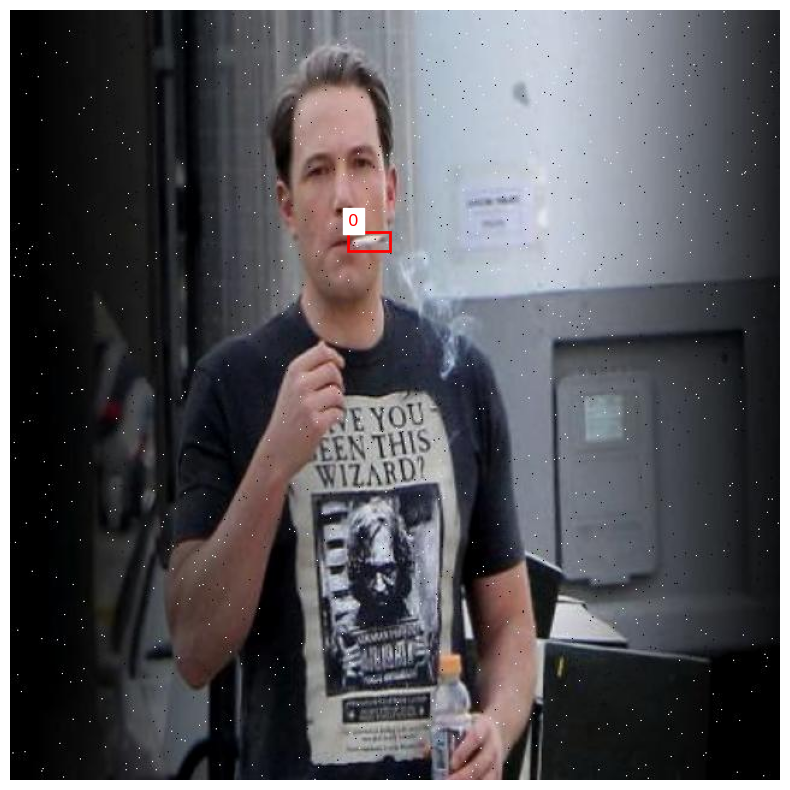

In [7]:
visualize_yolo_sample(df.iloc[10100])

In [8]:
from collections import defaultdict

def dataset_to_classes(df):
    result = defaultdict(set)

    for _, row in df.iterrows():
        with open(row.txt_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 1:
                    continue
                cls = int(float(parts[0]))
                result[row.dataset].add(cls)

    return {k: sorted(v) for k, v in result.items()}


In [9]:
dataset_classes = dataset_to_classes(df)
dataset_classes

{'cigar.v2i.yolo26': [0],
 'smoking.v1-smoker1.yolo26': [0],
 'project11.v1i.yolo26': [0],
 'VNTU_Object_Detection_YOLO8S.v8i.yolo26': [0],
 'CigDet_dataset': [0],
 'data_kaggle_smoke_eat_drink_phone': [0],
 'smokingProjec.v1i.yolo26': [0],
 'cigarette smokers.v5-rsd.yolo26': [0],
 'smoking26.v1i.yolo26': [0],
 'Smoking Detection.v5i.yolo26': [0],
 'iuhgiu786.v1i.yolo26': [0],
 'Smoking v2.v1i.yolo26': [0],
 'Smoking detection.v2i.yolo26': [0],
 'sigara deneme.v2i.yolo26': [0],
 'augmented.v1i.yolo26': [0],
 'Cigarette Vape Detection.v14i.yolo26': [0]}

## Split and concat

In [10]:
train_df = df[df['image_dir'].isin(['train', 'training', 'Train'])].reset_index(drop=True)
val_df = df[df['image_dir'].isin(['val', 'valid', 'validation', 'Val'])].reset_index(drop=True)
test_df = df[df['image_dir'].isin(['test', 'testing', 'Test'])].reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nUnique image_dir values: {df['image_dir'].unique()}")

Train: 8544, Val: 1240, Test: 920

Unique image_dir values: ['test' 'train' 'valid']


In [11]:
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
import numpy as np

In [12]:
class DetectionDataset(Dataset):
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row['image_path']).convert('RGB')

        boxes = []
        labels = []

        with open(row['txt_path'], 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])

                    img_width, img_height = img.size

                    x_min = (x_center - width / 2) * img_width
                    y_min = (y_center - height / 2) * img_height
                    x_max = (x_center + width / 2) * img_width
                    y_max = (y_center + height / 2) * img_height

                    boxes.append([x_min, y_min, x_max, y_max])
                    labels.append(class_id + 1)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {}
        target['boxes'] = boxes
        target['labels'] = labels
        target['image_id'] = torch.tensor([idx])

        if self.transforms:
            img = self.transforms(img)

        return img, target

def get_transform(train):
    transforms = []
    transforms.append(T.ToTensor())
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    return T.Compose(transforms)



In [13]:
train_dataset = DetectionDataset(train_df, get_transform(train=True))
val_dataset = DetectionDataset(val_df, get_transform(train=False))
test_dataset = DetectionDataset(test_df, get_transform(train=False))

print(f"Datasets created: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

Datasets created: train=8544, val=1240, test=920


In [14]:
def collate_fn(batch):
    return tuple(zip(*batch))



In [20]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print("DataLoaders created")

DataLoaders created


In [21]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


In [22]:
model = fasterrcnn_resnet50_fpn(weights='DEFAULT')

num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if "roi_heads.box_predictor" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)


model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-4},
        {"params": head_params, "lr": 3e-4},
    ],
    weight_decay=1e-4,
    betas=(0.9, 0.999),
)

lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6
)


print("Faster R-CNN model initialized")

Faster R-CNN model initialized


In [24]:
from tqdm import tqdm
import os

save_dir = Path('checkpoints_frcnn_adamw')
save_dir.mkdir(exist_ok=True)

In [ ]:
num_epochs = 20


train_losses = []
val_losses = []

for epoch in range(num_epochs):
    torch.cuda.empty_cache()
    model.train()
    epoch_loss = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
    for images, targets in pbar:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        pbar.set_postfix({'loss': losses.item()})
        torch.cuda.empty_cache()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            model.train()
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            val_loss += losses.item()
            model.eval()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    lr_scheduler.step()

    print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}')

    if (epoch + 1) % 5 == 0:
        checkpoint_path = save_dir / f'frcnn_epoch_{epoch+1}.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
        }, checkpoint_path)
        print(f'Checkpoint saved: {checkpoint_path}')

final_model_path = save_dir / 'frcnn_final.pth'
torch.save(model.state_dict(), final_model_path)
print(f'Final model saved: {final_model_path}')

Epoch 1/20: 100%|██████████| 267/267 [04:50<00:00,  1.09s/it, loss=0.205]


Epoch 1: Train Loss = 0.2539, Val Loss = 0.2159


Epoch 2/20: 100%|██████████| 267/267 [04:50<00:00,  1.09s/it, loss=0.236]


Epoch 2: Train Loss = 0.2111, Val Loss = 0.2033


Epoch 3/20: 100%|██████████| 267/267 [04:49<00:00,  1.08s/it, loss=0.207]


...

Epoch 11/20: 100%|██████████| 267/267 [04:52<00:00,  1.10s/it, loss=0.104] 


Epoch 11: Train Loss = 0.1127, Val Loss = 0.1939


Epoch 12/20: 100%|██████████| 267/267 [04:55<00:00,  1.11s/it, loss=0.103] 


Epoch 12: Train Loss = 0.1024, Val Loss = 0.2043


Epoch 13/20:  55%|█████▌    | 147/267 [02:43<02:13,  1.11s/it, loss=0.0758]

In [21]:
torch.cuda.empty_cache()

In [22]:
t = torch.cuda.get_device_properties(0).total_memory
r = torch.cuda.memory_reserved(0)
a = torch.cuda.memory_allocated(0)
f = r-a  # free inside reserved
t, r, a, f

(84974239744, 79825993728, 76576526848, 3249466880)

ValueError: x and y must have same first dimension, but have shapes (20,) and (2,)

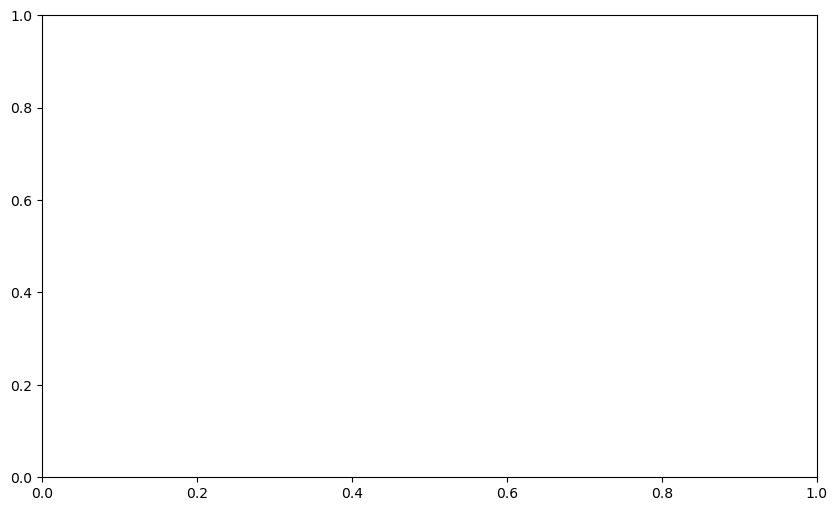

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Faster R-CNN Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('frcnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
from torchvision.ops import box_iou

def evaluate_model(model, data_loader, device, iou_threshold=0.5):
    model.eval()

    all_precisions = []
    all_recalls = []
    all_aps = []

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc='Evaluating'):
            images = list(img.to(device) for img in images)

            outputs = model(images)

            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes'].cpu()
                pred_scores = output['scores'].cpu()
                pred_labels = output['labels'].cpu()

                gt_boxes = target['boxes'].cpu()
                gt_labels = target['labels'].cpu()

                if len(pred_boxes) == 0 or len(gt_boxes) == 0:
                    continue

                score_threshold = 0.5
                mask = pred_scores > score_threshold
                pred_boxes = pred_boxes[mask]
                pred_labels = pred_labels[mask]
                pred_scores = pred_scores[mask]

                if len(pred_boxes) == 0:
                    all_precisions.append(0.0)
                    all_recalls.append(0.0)
                    continue

                ious = box_iou(pred_boxes, gt_boxes)

                matched_gt = set()
                tp = 0

                sorted_indices = torch.argsort(pred_scores, descending=True)

                for idx in sorted_indices:
                    max_iou, max_gt_idx = ious[idx].max(0)

                    if max_iou >= iou_threshold and max_gt_idx.item() not in matched_gt:
                        if pred_labels[idx] == gt_labels[max_gt_idx]:
                            tp += 1
                            matched_gt.add(max_gt_idx.item())

                precision = tp / len(pred_boxes) if len(pred_boxes) > 0 else 0
                recall = tp / len(gt_boxes) if len(gt_boxes) > 0 else 0

                all_precisions.append(precision)
                all_recalls.append(recall)

    avg_precision = np.mean(all_precisions)
    avg_recall = np.mean(all_recalls)
    f1 = 2 * avg_precision * avg_recall / (avg_precision + avg_recall) if (avg_precision + avg_recall) > 0 else 0

    return {
        'precision': avg_precision,
        'recall': avg_recall,
        'f1': f1,
        'mAP50': avg_precision
    }

print("Evaluating on validation set...")
val_metrics = evaluate_model(model, val_loader, device)
print(f"\nValidation Metrics:")
print(f"Precision: {val_metrics['precision']:.4f}")
print(f"Recall: {val_metrics['recall']:.4f}")
print(f"F1: {val_metrics['f1']:.4f}")
print(f"mAP@0.5: {val_metrics['mAP50']:.4f}")

print("\nEvaluating on test set...")
test_metrics = evaluate_model(model, test_loader, device)
print(f"\nTest Metrics:")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1: {test_metrics['f1']:.4f}")
print(f"mAP@0.5: {test_metrics['mAP50']:.4f}")

Evaluating on validation set...


Evaluating: 100%|██████████| 20/20 [00:21<00:00,  1.07s/it]



Validation Metrics:
Precision: 0.3087
Recall: 0.2488
F1: 0.2755
mAP@0.5: 0.3087

Evaluating on test set...


Evaluating: 100%|██████████| 15/15 [00:20<00:00,  1.34s/it]


Test Metrics:
Precision: 0.3331
Recall: 0.2370
F1: 0.2770
mAP@0.5: 0.3331


In [35]:
dataset_metrics = []

for dataset_name in df['dataset'].unique():
    dataset_samples = df[df['dataset'] == dataset_name]

    val_samples = dataset_samples[dataset_samples['image_dir'].isin(['val', 'valid', 'validation', 'Val'])]
    test_samples = dataset_samples[dataset_samples['image_dir'].isin(['test', 'testing', 'Test'])]

    print(f"\n{'='*60}")
    print(f"Dataset: {dataset_name}")
    print(f"Val samples: {len(val_samples)}, Test samples: {len(test_samples)}")

    for split_name, split_samples in [('val', val_samples), ('test', test_samples)]:
        if len(split_samples) == 0:
            continue

        split_dataset = DetectionDataset(split_samples, get_transform(train=False))
        split_loader = DataLoader(split_dataset, batch_size=4, shuffle=False, num_workers=4, collate_fn=collate_fn)

        metrics = evaluate_model(model, split_loader, device)

        dataset_metrics.append({
            'dataset': dataset_name,
            'split': split_name,
            'samples': len(split_samples),
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'f1': metrics['f1'],
            'mAP50': metrics['mAP50']
        })

        print(f"{split_name.upper()} - Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['f1']:.4f}, mAP@0.5: {metrics['mAP50']:.4f}")

frcnn_metrics_df = pd.DataFrame(dataset_metrics)
frcnn_metrics_df.to_csv('frcnn_per_dataset_metrics.csv', index=False)
print("\nMetrics saved to frcnn_per_dataset_metrics.csv")
frcnn_metrics_df

/home/aysurkov/.local/lib/python3.10/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Dataset: cigar.v2i.yolo26
Val samples: 14, Test samples: 12


Evaluating: 100%|██████████| 4/4 [00:01<00:00,  3.37it/s]


VAL - Precision: 0.4286, Recall: 0.4286, F1: 0.4286, mAP@0.5: 0.4286


Evaluating: 100%|██████████| 3/3 [00:00<00:00,  5.54it/s]


...

Evaluating: 100%|██████████| 72/72 [00:06<00:00, 11.67it/s]


VAL - Precision: 0.2217, Recall: 0.2411, F1: 0.2310, mAP@0.5: 0.2217


Evaluating: 100%|██████████| 38/38 [00:03<00:00, 11.14it/s]

TEST - Precision: 0.2109, Recall: 0.2188, F1: 0.2148, mAP@0.5: 0.2109

Metrics saved to frcnn_per_dataset_metrics.csv


,dataset,split,samples,precision,recall,f1,mAP50
0,cigar.v2i.yolo26,val,14,0.428571,0.428571,0.428571,0.428571
1,cigar.v2i.yolo26,test,12,0.166667,0.166667,0.166667,0.166667
2,smoking.v1-smoker1.yolo26,val,115,0.407681,0.330145,0.364839,0.407681
3,smoking.v1-smoker1.yolo26,test,119,0.388604,0.275600,0.322489,0.388604
4,project11.v1i.yolo26,val,5,0.470000,0.539286,0.502265,0.470000
5,project11.v1i.yolo26,test,6,0.000000,0.000000,0.000000,0.000000
6,VNTU_Object_Detection_YOLO8S.v8i.yolo26,val,101,0.203333,0.225000,0.213619,0.203333
7,VNTU_Object_Detection_YOLO8S.v8i.yolo26,test,21,0.175000,0.250000,0.205882,0.175000
8,CigDet_dataset,test,2,0.000000,0.000000,0.000000,0.000000
9,data_kaggle_smoke_eat_drink_phone,val,213,0.180095,0.167062,0.173334,0.180095


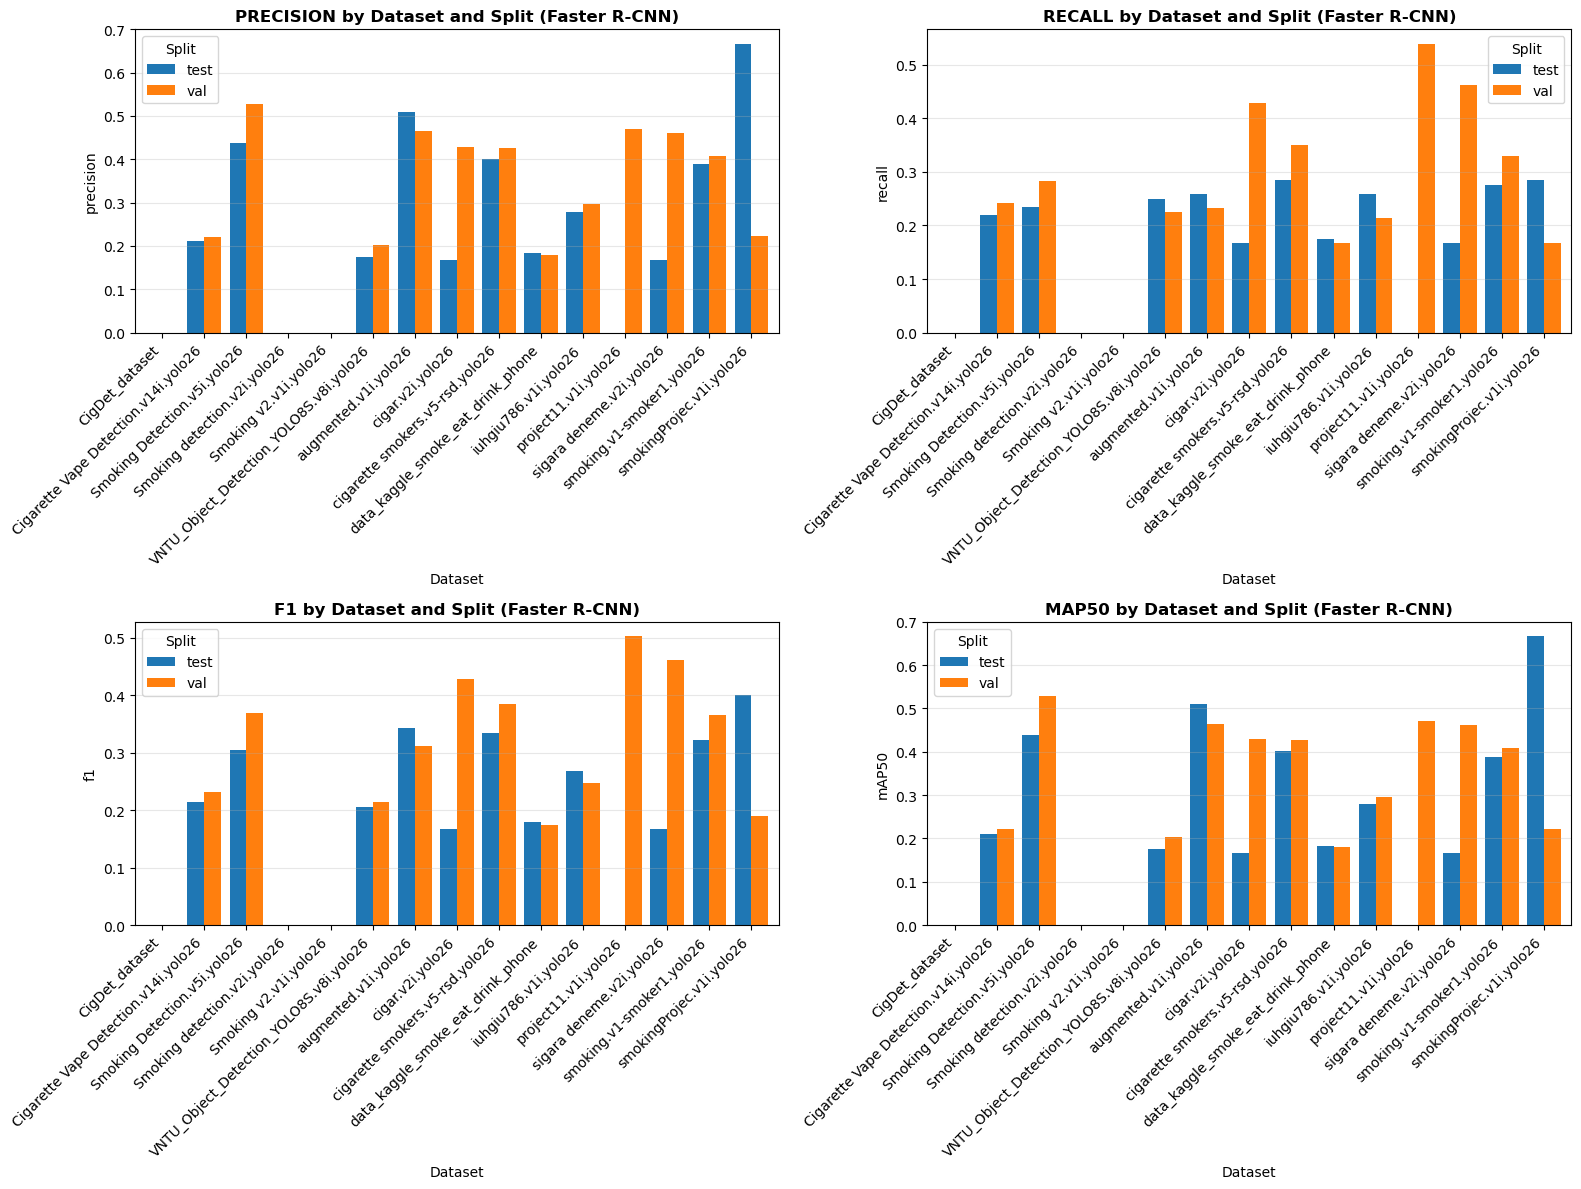

In [37]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, metric in enumerate(['precision', 'recall', 'f1', 'mAP50']):
    ax = axes[idx // 2, idx % 2]

    pivot_data = frcnn_metrics_df.pivot(index='dataset', columns='split', values=metric)
    pivot_data.plot(kind='bar', ax=ax, width=0.8)

    ax.set_title(f'{metric.upper()} by Dataset and Split (Faster R-CNN)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dataset', fontsize=10)
    ax.set_ylabel(metric, fontsize=10)
    ax.legend(title='Split')
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('frcnn_per_dataset_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

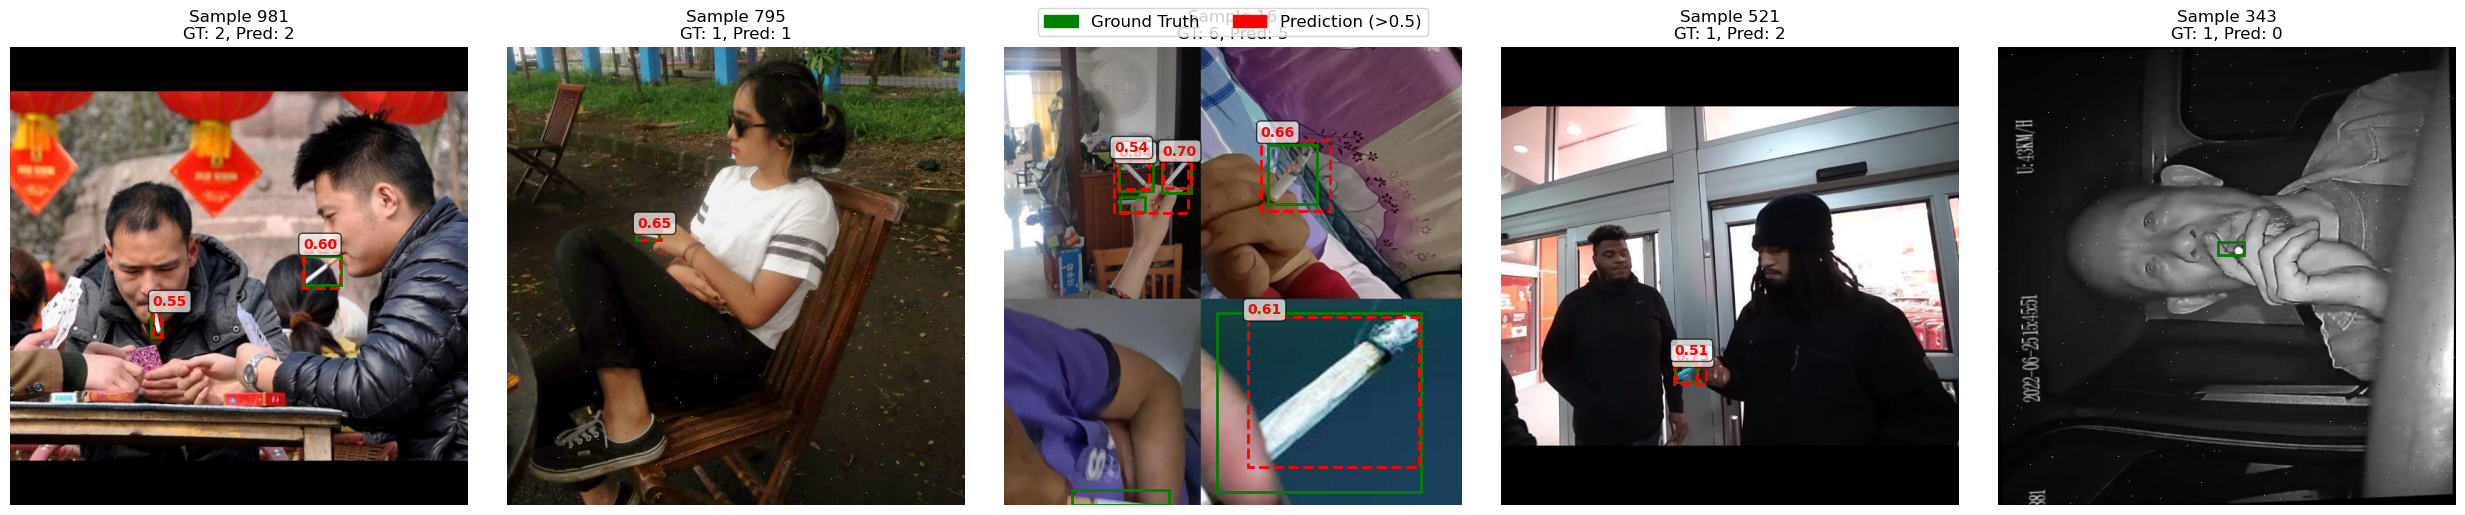

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

model.eval()

random_indices = random.sample(range(len(val_dataset)), min(5, len(val_dataset)))

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

with torch.no_grad():
    for idx, sample_idx in enumerate(random_indices):
        image, target = val_dataset[sample_idx]

        image_tensor = image.unsqueeze(0).to(device)
        prediction = model(image_tensor)[0]

        image_np = image.permute(1, 2, 0).cpu().numpy()

        ax = axes[idx]
        ax.imshow(image_np)

        gt_boxes = target['boxes'].cpu().numpy()
        for box in gt_boxes:
            x_min, y_min, x_max, y_max = box
            rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                     linewidth=2, edgecolor='green', facecolor='none', label='GT')
            ax.add_patch(rect)

        pred_boxes = prediction['boxes'].cpu().numpy()
        pred_scores = prediction['scores'].cpu().numpy()

        for box, score in zip(pred_boxes, pred_scores):
            if score > 0.5:
                x_min, y_min, x_max, y_max = box
                rect = patches.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                         linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
                ax.add_patch(rect)
                ax.text(x_min, y_min - 5, f'{score:.2f}',
                       color='red', fontsize=10, weight='bold',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

        ax.set_title(f'Sample {sample_idx}\nGT: {len(gt_boxes)}, Pred: {(pred_scores > 0.5).sum()}')
        ax.axis('off')

green_patch = patches.Patch(color='green', label='Ground Truth')
red_patch = patches.Patch(color='red', label='Prediction (>0.5)')
fig.legend(handles=[green_patch, red_patch], loc='upper center', ncol=2, fontsize=12)

plt.tight_layout()
plt.savefig('frcnn_predictions_validation.png', dpi=150, bbox_inches='tight')
plt.show()